# CNN on text data

In [2]:
import re
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install gensim
from gensim.models import KeyedVectors
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader


### Load Dataset

In [3]:
raw_data = pd.read_csv('IMDB Dataset.csv')
print(raw_data.info())
print(raw_data.head())
print(Counter(raw_data['sentiment']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Counter({'positive': 25000, 'negative': 25000})


## Data Exploration, cleaning and tokenization

In [4]:


def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>","",text)
    text = re.sub(r"[^a-zA-Z\s]","",text)
    return text.split()


tokenized_reviews = [tokenize(review) for review in raw_data['review']]
all_tokens = [token for review in tokenized_reviews for token in review]
vocab = set(all_tokens)
word_freq = Counter(all_tokens)
rare_words = [word for word, count in word_freq.items() if count == 1]

print("Vocab size:", len(vocab))
print("Top 20 words:", word_freq.most_common(20))
print("Example tokens:", tokenized_reviews[0][:30])
print("Rare words:", len(rare_words))
print(rare_words[:10])

Vocab size: 214620
Top 20 words: [('the', 650812), ('and', 319428), ('a', 319263), ('of', 288081), ('to', 266297), ('is', 210068), ('in', 183153), ('it', 151365), ('i', 145576), ('this', 145500), ('that', 135806), ('was', 95187), ('as', 90060), ('with', 86554), ('for', 86149), ('movie', 83578), ('but', 80337), ('film', 74514), ('on', 66316), ('not', 59512)]
Example tokens: ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'methe', 'first', 'thing', 'that']
Rare words: 133033
['manyaryans', 'romanceoz', 'viewingthats', 'oldtimebbc', 'polari', 'halliwells', 'zombieok', 'petter', 'habitatthe', 'discerns']


In [5]:
def avg(ls):
    return sum(ls) / len(ls)

lengths = [len(review) for review in tokenized_reviews]

longest_review = max(lengths)
shortest_review = min(lengths)
avg_review = avg(lengths)

print("Longest review length:", longest_review)
print("Shortest review length:", shortest_review)
print("Average review length:", avg_review)

Longest review length: 2441
Shortest review length: 4
Average review length: 225.18978


### rare words removal(optional)

In [6]:
# def remove_rare_words(ls,rare_words):
#     new_ls = []
#     for token in ls:
#         if token not in rare_words:
#             new_ls.append(token)
#     return new_ls
# rare_words_set = set(rare_words)
# for i,review in enumerate(tokenized_reviews):
#     tokenized_reviews[i] = remove_rare_words(review,rare_words_set)

In [7]:
# lengths = [len(review) for review in tokenized_reviews]

# longest_review = max(lengths)
# shortest_review = min(lengths)
# avg_review = avg(lengths)
# vocab = vocab - rare_words_set
# print("new vocab size : ",len(vocab))
# print("Longest review length:", longest_review)
# print("Shortest review length:", shortest_review)
# print("Average review length:", avg_review)

In [8]:
word2idx = {word:i+2 for i,word in enumerate(vocab)}

word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

def encode(tokens):
    return [word2idx.get(word,1) for word in tokens]

encoded_reviews = [encode(review) for review in tokenized_reviews]


In [9]:
MAX_LEN = longest_review//5

def pad(seq):
    if len(seq) > MAX_LEN:
        return seq[:MAX_LEN]
    return seq + [0] * (MAX_LEN - len(seq))


padded_reviews = [pad(r) for r in encoded_reviews]

### Train test val split

In [10]:
labels = raw_data["sentiment"].map({
    "positive" : 1,
    "negative" : 0
}).values

X_train,X_test,y_train,y_test = train_test_split(
    padded_reviews,
    labels,
    test_size = 0.1,
    stratify = labels
)

X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.1,
    stratify = y_train
)

print(len(X_train))
print(len(X_val))
print(len(X_test))

40500
4500
5000


### convert to tensors

In [11]:

X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### create Data Loader

In [12]:

class IMDBDataset(Dataset):

    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [13]:
train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)
test_dataset = IMDBDataset(X_test, y_test)

In [14]:

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

### load word2vec

In [15]:
w2v = api.load("word2vec-google-news-300")

In [16]:
embedding_dim = w2v.vector_size
vocab_size = len(word2idx)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in word2idx.items():

    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [17]:
embedding_matrix = torch.tensor(embedding_matrix,dtype = torch.float32)

In [18]:
embedding_layer = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze = False
)

## CNN model for text (Basic)

In [19]:
class TextCNN(nn.Module):

    def __init__(self, embedding_matrix):

        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False
        )

        self.conv1 = nn.Conv2d(1, 50, (3, embed_dim))
        self.conv2 = nn.Conv2d(1, 50, (4, embed_dim))

        self.fc = nn.Linear(100, 1)

    def forward(self, x):

        x = self.embedding(x)

        x = x.unsqueeze(1)

        x1 = F.relu(self.conv1(x)).squeeze(3)
        x2 = F.relu(self.conv2(x)).squeeze(3)

        x1 = F.max_pool1d(x1, x1.size(2)).squeeze(2)
        x2 = F.max_pool1d(x2, x2.size(2)).squeeze(2)

        x = torch.cat((x1, x2), dim=1)

        x = self.fc(x)

        return torch.sigmoid(x).squeeze(-1)

In [62]:
model = TextCNN(embedding_matrix)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [63]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [64]:
EPOCHS = 3
LOG_STEPS = 50
EVAL_STEPS = 50

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model.train()

    for step, (X_batch, y_batch) in enumerate(train_loader):
        # Training
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_history.append(loss.item())

        if (step + 1) % LOG_STEPS == 0:
            print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Train = Loss: {loss.item():.4f}",end="")

        # Validation
        if (step + 1) % EVAL_STEPS == 0:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch_val, y_batch_val in val_loader:
                    X_batch_val = X_batch_val.to(device)
                    y_batch_val = y_batch_val.to(device)

                    preds_val = model(X_batch_val)
                    batch_loss_val = criterion(preds_val, y_batch_val)
                    val_loss += batch_loss_val.item()

                    preds_val_binary = (preds_val > 0.5).float()
                    val_correct += (preds_val_binary == y_batch_val).sum().item()
                    val_total += y_batch_val.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total

            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_acc)

            print(f" Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

            model.train()

    print(f"=== Epoch {epoch+1} Completed ===")

Epoch: [1/3] | Step: [50/317] | Train = Loss: 0.5611 Val Loss: 0.4933 | Val Acc: 0.8129

Epoch: [1/3] | Step: [100/317] | Train = Loss: 0.3870 Val Loss: 0.3522 | Val Acc: 0.8500

Epoch: [1/3] | Step: [150/317] | Train = Loss: 0.3132 Val Loss: 0.3091 | Val Acc: 0.8709

Epoch: [1/3] | Step: [200/317] | Train = Loss: 0.3207 Val Loss: 0.2897 | Val Acc: 0.8760

Epoch: [1/3] | Step: [250/317] | Train = Loss: 0.3148 Val Loss: 0.2739 | Val Acc: 0.8838

Epoch: [1/3] | Step: [300/317] | Train = Loss: 0.2292 Val Loss: 0.2561 | Val Acc: 0.8958

=== Epoch 1 Completed ===
Epoch: [2/3] | Step: [50/317] | Train = Loss: 0.2009 Val Loss: 0.2497 | Val Acc: 0.8953

Epoch: [2/3] | Step: [100/317] | Train = Loss: 0.1430 Val Loss: 0.2469 | Val Acc: 0.8991

Epoch: [2/3] | Step: [150/317] | Train = Loss: 0.1752 Val Loss: 0.2415 | Val Acc: 0.8969

Epoch: [2/3] | Step: [200/317] | Train = Loss: 0.1646 Val Loss: 0.2391 | Val Acc: 0.8967

Epoch: [2/3] | Step: [250/317] | Train = Loss: 0.1755 Val Loss: 0.2401 | Val

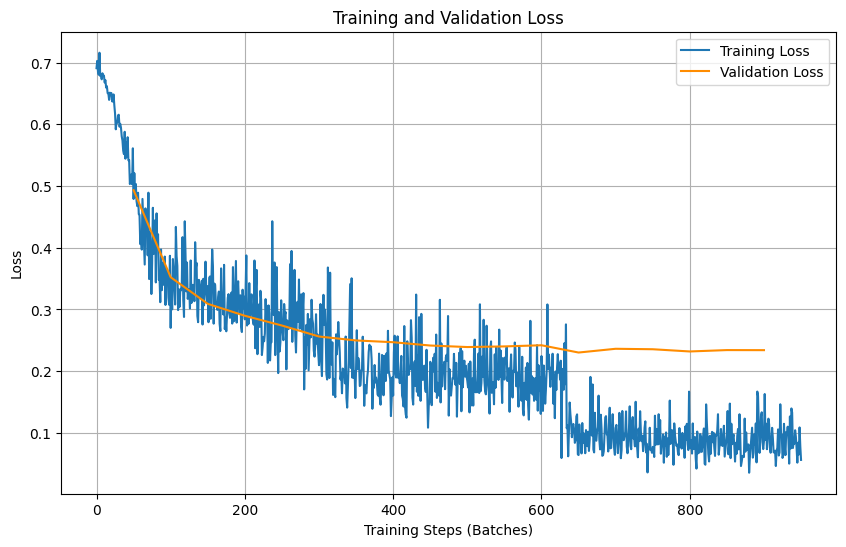

In [65]:
import matplotlib.pyplot as plt

val_steps = [i * EVAL_STEPS for i in range(1, len(val_loss_history) + 1)]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_steps, val_loss_history, label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        preds = (preds > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8894


In [67]:
def predict_sentiment(model,review_text):
    model.eval()

    tokens = tokenize(review_text)

    encoded_review = [word2idx.get(word, 1) for word in tokens]

    if len(encoded_review) > MAX_LEN:
        padded_review = encoded_review[:MAX_LEN]
    else:
        padded_review = encoded_review + [0] * (MAX_LEN - len(encoded_review))

    input_tensor = torch.tensor(padded_review, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(input_tensor)
        probability = prediction.item()

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability


In [68]:
review = "It was okay, not the best but definitely not the worst I've seen."
sentiment, prob = predict_sentiment(model,review)
print(f"Review: '{review}'")
print(f"Prediction: {sentiment} (Probability: {prob:.4f})\n")

Review: 'It was okay, not the best but definitely not the worst I've seen.'
Prediction: Negative (Probability: 0.0034)



## Model2 (large number of filters)

In [69]:
class TextCNN2(nn.Module):

    def __init__(self, embedding_matrix):

        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False
        )

        self.conv1 = nn.Conv2d(1, 100, (3, embed_dim))
        self.conv2 = nn.Conv2d(1, 100, (4, embed_dim))

        self.fc = nn.Linear(200, 1)

    def forward(self, x):

        x = self.embedding(x)

        x = x.unsqueeze(1)

        x1 = F.relu(self.conv1(x)).squeeze(3)
        x2 = F.relu(self.conv2(x)).squeeze(3)

        x1 = F.max_pool1d(x1, x1.size(2)).squeeze(2)
        x2 = F.max_pool1d(x2, x2.size(2)).squeeze(2)

        x = torch.cat((x1, x2), dim=1)

        x = self.fc(x)

        return torch.sigmoid(x).squeeze(-1)

In [70]:
model2 = TextCNN2(embedding_matrix)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = model2.to(device)

In [71]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model2.parameters(),
    lr = 0.001
)

In [72]:
EPOCHS = 3
LOG_STEPS = 50
EVAL_STEPS = 50

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model2.train()

    for step, (X_batch, y_batch) in enumerate(train_loader):
        # Training
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model2(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_history.append(loss.item())

        if (step + 1) % LOG_STEPS == 0:
            print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Train Batch Loss: {loss.item():.4f}",end="")

        # Validation
        if (step + 1) % EVAL_STEPS == 0:
            model2.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch_val, y_batch_val in val_loader:
                    X_batch_val = X_batch_val.to(device)
                    y_batch_val = y_batch_val.to(device)

                    preds_val = model2(X_batch_val)
                    batch_loss_val = criterion(preds_val, y_batch_val)
                    val_loss += batch_loss_val.item()

                    preds_val_binary = (preds_val > 0.5).float()
                    val_correct += (preds_val_binary == y_batch_val).sum().item()
                    val_total += y_batch_val.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total

            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_acc)

            print(f" Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

            model2.train()

    print(f"=== Epoch {epoch+1} Completed ===")

Epoch: [1/3] | Step: [50/317] | Train Batch Loss: 0.5017 Val Loss: 0.4814 | Val Acc: 0.8087

Epoch: [1/3] | Step: [100/317] | Train Batch Loss: 0.2818 Val Loss: 0.3428 | Val Acc: 0.8451

Epoch: [1/3] | Step: [150/317] | Train Batch Loss: 0.2680 Val Loss: 0.3010 | Val Acc: 0.8747

Epoch: [1/3] | Step: [200/317] | Train Batch Loss: 0.2823 Val Loss: 0.2917 | Val Acc: 0.8769

Epoch: [1/3] | Step: [250/317] | Train Batch Loss: 0.3028 Val Loss: 0.2688 | Val Acc: 0.8878

Epoch: [1/3] | Step: [300/317] | Train Batch Loss: 0.3306 Val Loss: 0.2647 | Val Acc: 0.8893

=== Epoch 1 Completed ===
Epoch: [2/3] | Step: [50/317] | Train Batch Loss: 0.1764 Val Loss: 0.2416 | Val Acc: 0.8980

Epoch: [2/3] | Step: [100/317] | Train Batch Loss: 0.1735 Val Loss: 0.2516 | Val Acc: 0.8904

Epoch: [2/3] | Step: [150/317] | Train Batch Loss: 0.1667 Val Loss: 0.2362 | Val Acc: 0.9011

Epoch: [2/3] | Step: [200/317] | Train Batch Loss: 0.1223 Val Loss: 0.2317 | Val Acc: 0.9036

Epoch: [2/3] | Step: [250/317] | Tra

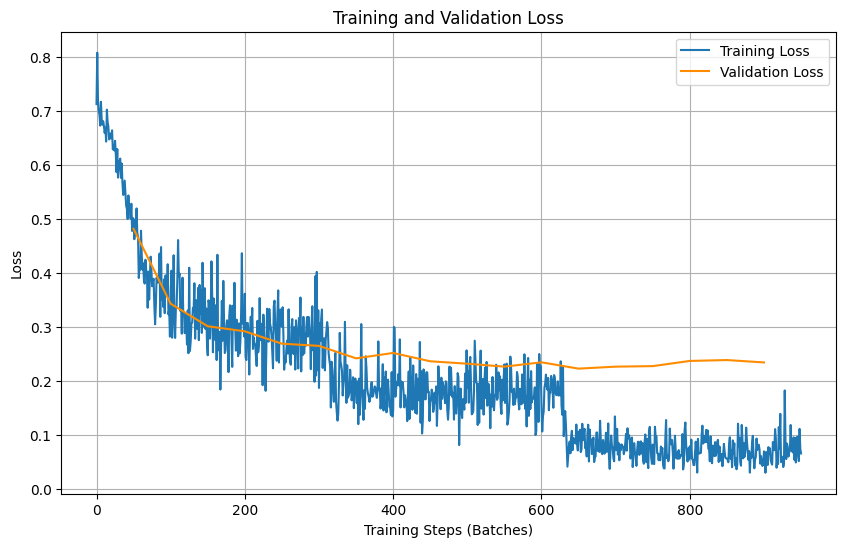

In [73]:
import matplotlib.pyplot as plt

val_steps = [i * EVAL_STEPS for i in range(1, len(val_loss_history) + 1)]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_steps, val_loss_history, label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [74]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model2(X_batch)

        preds = (preds > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8982


In [75]:
review = "It was okay, not the best but definitely not the worst I've seen."
sentiment, prob = predict_sentiment(model2,review)
print(f"Review: '{review}'")
print(f"Prediction: {sentiment} (Probability: {prob:.4f})\n")

Review: 'It was okay, not the best but definitely not the worst I've seen.'
Prediction: Negative (Probability: 0.0052)



### Model3 (More number of conv layers + dropout)

In [76]:

class TextCNN3(nn.Module):

    def __init__(self, embedding_matrix):

        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False
        )

        self.conv1 = nn.Conv2d(1, 100, (3, embed_dim))
        self.conv2 = nn.Conv2d(1, 100, (4, embed_dim))
        self.conv3 = nn.Conv2d(1, 100, (5, embed_dim))

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(300, 1)

    def forward(self, x):

        x = self.embedding(x)           # (batch, seq_len, embed_dim)

        x = x.unsqueeze(1)              # (batch, 1, seq_len, embed_dim)

        x1 = F.relu(self.conv1(x)).squeeze(3)
        x2 = F.relu(self.conv2(x)).squeeze(3)
        x3 = F.relu(self.conv3(x)).squeeze(3)

        x1 = F.max_pool1d(x1, x1.size(2)).squeeze(2)
        x2 = F.max_pool1d(x2, x2.size(2)).squeeze(2)
        x3 = F.max_pool1d(x3, x3.size(2)).squeeze(2)

        x = torch.cat((x1, x2, x3), dim=1)

        x = self.dropout(x)

        x = self.fc(x)

        return torch.sigmoid(x).squeeze(-1)

In [77]:
model3 = TextCNN3(embedding_matrix)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model3 = model3.to(device)


In [78]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model3.parameters(),
    lr = 0.001
)

In [79]:
EPOCHS = 3
LOG_STEPS = 50
EVAL_STEPS = 50

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model3.train()

    for step, (X_batch, y_batch) in enumerate(train_loader):
        # Training
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model3(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_history.append(loss.item())

        if (step + 1) % LOG_STEPS == 0:
            print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Train Batch Loss: {loss.item():.4f}",end = " ")

        # Validation
        if (step + 1) % EVAL_STEPS == 0:
            model3.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch_val, y_batch_val in val_loader:
                    X_batch_val = X_batch_val.to(device)
                    y_batch_val = y_batch_val.to(device)

                    preds_val = model3(X_batch_val)
                    batch_loss_val = criterion(preds_val, y_batch_val)
                    val_loss += batch_loss_val.item()

                    preds_val_binary = (preds_val > 0.5).float()
                    val_correct += (preds_val_binary == y_batch_val).sum().item()
                    val_total += y_batch_val.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total

            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_acc)

            print(f" Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

            model3.train()

    print(f"=== Epoch {epoch+1} Completed ===")

Epoch: [1/3] | Step: [50/317] | Train Batch Loss: 0.6161  Val Loss: 0.5141 | Val Acc: 0.7973

Epoch: [1/3] | Step: [100/317] | Train Batch Loss: 0.3899  Val Loss: 0.3652 | Val Acc: 0.8413

Epoch: [1/3] | Step: [150/317] | Train Batch Loss: 0.4265  Val Loss: 0.3122 | Val Acc: 0.8658

Epoch: [1/3] | Step: [200/317] | Train Batch Loss: 0.4041  Val Loss: 0.2977 | Val Acc: 0.8727

Epoch: [1/3] | Step: [250/317] | Train Batch Loss: 0.3070  Val Loss: 0.2841 | Val Acc: 0.8780

Epoch: [1/3] | Step: [300/317] | Train Batch Loss: 0.3345  Val Loss: 0.2738 | Val Acc: 0.8867

=== Epoch 1 Completed ===
Epoch: [2/3] | Step: [50/317] | Train Batch Loss: 0.2258  Val Loss: 0.2587 | Val Acc: 0.8907

Epoch: [2/3] | Step: [100/317] | Train Batch Loss: 0.2683  Val Loss: 0.2622 | Val Acc: 0.8860

Epoch: [2/3] | Step: [150/317] | Train Batch Loss: 0.3264  Val Loss: 0.2579 | Val Acc: 0.8860

Epoch: [2/3] | Step: [200/317] | Train Batch Loss: 0.2031  Val Loss: 0.2474 | Val Acc: 0.8889

Epoch: [2/3] | Step: [250/

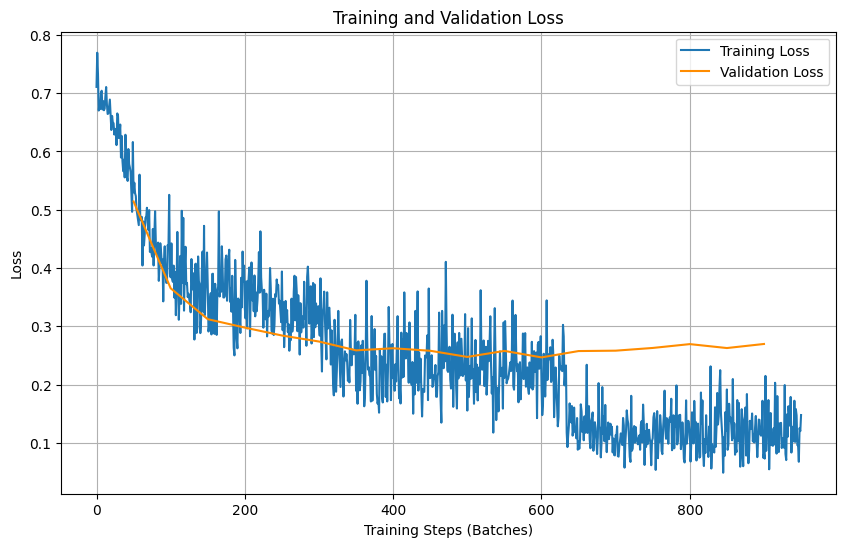

In [80]:
import matplotlib.pyplot as plt

val_steps = [i * EVAL_STEPS for i in range(1, len(val_loss_history) + 1)]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_steps, val_loss_history, label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [81]:
model3.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model3(X_batch)

        preds = (preds > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8894


In [82]:
review = "It was okay, not the best but definitely not the worst I've seen."
sentiment, prob = predict_sentiment(model3,review)
print(f"Review: '{review}'")
print(f"Prediction: {sentiment} (Probability: {prob:.4f})\n")

Review: 'It was okay, not the best but definitely not the worst I've seen.'
Prediction: Negative (Probability: 0.0175)



### model4 (Regularization - Dropout  l1 l2 )

In [83]:
model4 = TextCNN3(embedding_matrix)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model4 = model4.to(device)

In [84]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model4.parameters(),
    lr = 0.001,
    weight_decay=1e-4
)

In [85]:
EPOCHS = 3
LOG_STEPS = 50
EVAL_STEPS = 50

l1_lambda = 1e-5

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model4.train()

    for step, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model4(X_batch)


        base_loss = criterion(preds, y_batch)

        # L1 Regularization
        l1_penalty = 0
        for name, param in model4.named_parameters():
            if 'embedding' not in name:
                l1_penalty += torch.sum(torch.abs(param))

        # Total loss for backpropagation
        loss = base_loss + l1_lambda * l1_penalty

        loss.backward()
        optimizer.step()

        train_loss_history.append(base_loss.item())

        if (step + 1) % LOG_STEPS == 0:
            # We print the base_loss here too, so the numbers make sense
            print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Train Base Loss: {base_loss.item():.4f}", end="")
        # Validation
        if (step + 1) % EVAL_STEPS == 0:
            model4.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch_val, y_batch_val in val_loader:
                    X_batch_val = X_batch_val.to(device)
                    y_batch_val = y_batch_val.to(device)

                    preds_val = model4(X_batch_val)
                    batch_loss_val = criterion(preds_val, y_batch_val)

                    val_loss += batch_loss_val.item()

                    preds_val_binary = (preds_val > 0.5).float()
                    val_correct += (preds_val_binary == y_batch_val).sum().item()
                    val_total += y_batch_val.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total

            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_acc)

            print(f" Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

            model4.train()

    print(f"=== Epoch {epoch+1} Completed ===")

Epoch: [1/3] | Step: [50/317] | Train Base Loss: 0.5848 Val Loss: 0.5340 | Val Acc: 0.8087

Epoch: [1/3] | Step: [100/317] | Train Base Loss: 0.3956 Val Loss: 0.3777 | Val Acc: 0.8431

Epoch: [1/3] | Step: [150/317] | Train Base Loss: 0.4009 Val Loss: 0.3497 | Val Acc: 0.8500

Epoch: [1/3] | Step: [200/317] | Train Base Loss: 0.3403 Val Loss: 0.3221 | Val Acc: 0.8633

Epoch: [1/3] | Step: [250/317] | Train Base Loss: 0.3998 Val Loss: 0.3111 | Val Acc: 0.8676

Epoch: [1/3] | Step: [300/317] | Train Base Loss: 0.2661 Val Loss: 0.3003 | Val Acc: 0.8713

=== Epoch 1 Completed ===
Epoch: [2/3] | Step: [50/317] | Train Base Loss: 0.3377 Val Loss: 0.2931 | Val Acc: 0.8771

Epoch: [2/3] | Step: [100/317] | Train Base Loss: 0.2443 Val Loss: 0.2868 | Val Acc: 0.8791

Epoch: [2/3] | Step: [150/317] | Train Base Loss: 0.3676 Val Loss: 0.2797 | Val Acc: 0.8856

Epoch: [2/3] | Step: [200/317] | Train Base Loss: 0.3317 Val Loss: 0.2826 | Val Acc: 0.8800

Epoch: [2/3] | Step: [250/317] | Train Base Lo

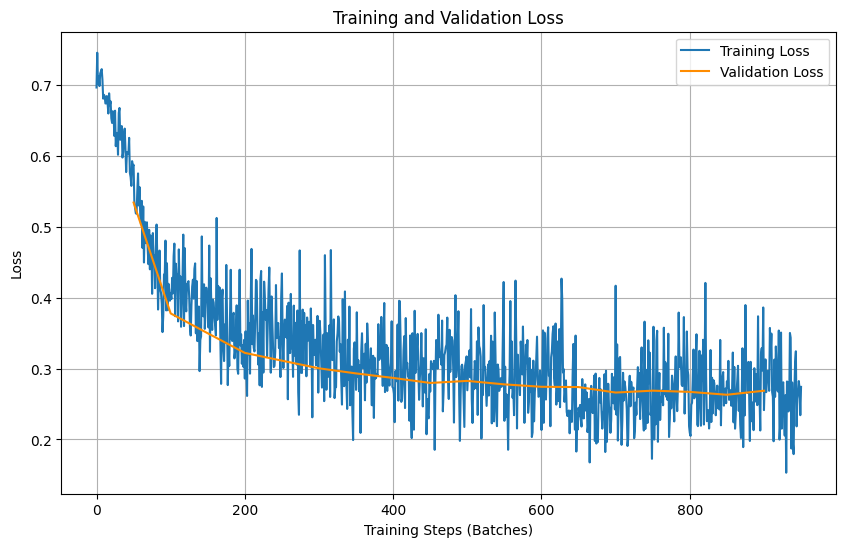

In [86]:
import matplotlib.pyplot as plt

val_steps = [i * EVAL_STEPS for i in range(1, len(val_loss_history) + 1)]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_steps, val_loss_history, label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
model4.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model4(X_batch)

        preds = (preds > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8846


In [88]:
review = "It was okay, not the best but definitely not the worst I've seen."
sentiment, prob = predict_sentiment(model4,review)
print(f"Review: '{review}'")
print(f"Prediction: {sentiment} (Probability: {prob:.4f})\n")

Review: 'It was okay, not the best but definitely not the worst I've seen.'
Prediction: Negative (Probability: 0.0233)



## Glove embeddings

In [89]:
w2v = api.load("glove-wiki-gigaword-300")

In [90]:
glove = w2v
embedding_dim = glove.vector_size
vocab_size = len(word2idx)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in word2idx.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))



In [91]:
embedding_matrix = torch.tensor(embedding_matrix,dtype = torch.float32)

In [92]:
embedding_layer = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze = False
)

In [93]:
model5 = TextCNN3(embedding_matrix)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model5 = model5.to(device)


In [94]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model5.parameters(),
    lr = 0.001,
    weight_decay=1e-4
)

In [95]:
EPOCHS = 3
LOG_STEPS = 50
EVAL_STEPS = 50

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model5.train()

    for step, (X_batch, y_batch) in enumerate(train_loader):
        # Training
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model5(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_history.append(loss.item())

        if (step + 1) % LOG_STEPS == 0:
            print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Train Batch Loss: {loss.item():.4f}",end = " ")

        # Validation
        if (step + 1) % EVAL_STEPS == 0:
            model5.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch_val, y_batch_val in val_loader:
                    X_batch_val = X_batch_val.to(device)
                    y_batch_val = y_batch_val.to(device)

                    preds_val = model5(X_batch_val)
                    batch_loss_val = criterion(preds_val, y_batch_val)
                    val_loss += batch_loss_val.item()

                    preds_val_binary = (preds_val > 0.5).float()
                    val_correct += (preds_val_binary == y_batch_val).sum().item()
                    val_total += y_batch_val.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total

            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_acc)

            print(f" Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

            model5.train()

    print(f"=== Epoch {epoch+1} Completed ===")

Epoch: [1/3] | Step: [50/317] | Train Batch Loss: 0.5555  Val Loss: 0.5180 | Val Acc: 0.8018

Epoch: [1/3] | Step: [100/317] | Train Batch Loss: 0.3696  Val Loss: 0.3813 | Val Acc: 0.8382

Epoch: [1/3] | Step: [150/317] | Train Batch Loss: 0.3750  Val Loss: 0.3402 | Val Acc: 0.8582

Epoch: [1/3] | Step: [200/317] | Train Batch Loss: 0.3065  Val Loss: 0.3393 | Val Acc: 0.8498

Epoch: [1/3] | Step: [250/317] | Train Batch Loss: 0.3774  Val Loss: 0.3068 | Val Acc: 0.8720

Epoch: [1/3] | Step: [300/317] | Train Batch Loss: 0.3253  Val Loss: 0.2947 | Val Acc: 0.8764

=== Epoch 1 Completed ===
Epoch: [2/3] | Step: [50/317] | Train Batch Loss: 0.2782  Val Loss: 0.2875 | Val Acc: 0.8784

Epoch: [2/3] | Step: [100/317] | Train Batch Loss: 0.3362  Val Loss: 0.2764 | Val Acc: 0.8871

Epoch: [2/3] | Step: [150/317] | Train Batch Loss: 0.2020  Val Loss: 0.2766 | Val Acc: 0.8884

Epoch: [2/3] | Step: [200/317] | Train Batch Loss: 0.2380  Val Loss: 0.2724 | Val Acc: 0.8891

Epoch: [2/3] | Step: [250/

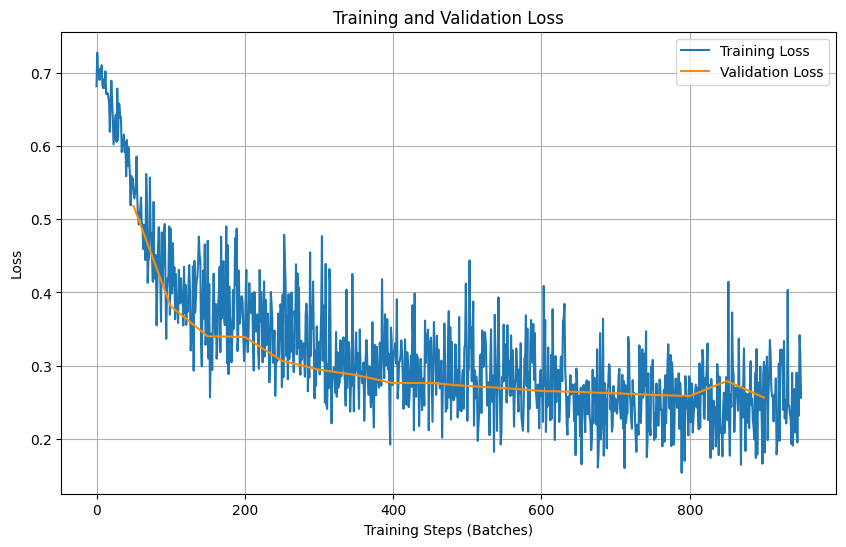

In [96]:
import matplotlib.pyplot as plt

val_steps = [i * EVAL_STEPS for i in range(1, len(val_loss_history) + 1)]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_steps, val_loss_history, label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
model5.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model5(X_batch)

        preds = (preds > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8828


In [98]:
review = "It was okay, not the best but definitely not the worst I've seen."
sentiment, prob = predict_sentiment(model5,review)
print(f"Review: '{review}'")
print(f"Prediction: {sentiment} (Probability: {prob:.4f})\n")

Review: 'It was okay, not the best but definitely not the worst I've seen.'
Prediction: Negative (Probability: 0.0416)



## model1 vs model2

**Change:** Increased the number of convolution filters from 50 to 100 per kernel size.

**Observation:** More filters give the model more feature detectors (for both 3-gram and 4-gram patterns), so Model 2 has higher capacity than Model 1. However, based on the graphs, Graph 2 does not significantly outperform Graph 1 on validation loss. This suggests that raw model capacity is not the main bottleneck for this dataset. Without stronger regularization, the larger model can learn training patterns faster but does not translate into clear validation gains.

## model2 vs model3 - Dropout

**Change:** added a third convolution layer with a 5-gram kernel and introduced `Dropout(0.5)`.

**Observation:** The additional 5-gram filter helps the model capture longer phrases and broader semantic context, which can be useful for sentiment analysis where meaning often depends on multi-word expressions.

**Dropout effect:** In graph 3, the validation loss appears more stable and remains close to `0.25` instead of rising near the end of training. It also follows the training loss curve more closely. This suggests that dropout helps reduce overfitting by preventing the model from relying too heavily on a small set of features.

## model3 vs model4 - L2 regularization

**Change:** trained model 3 with L2 regularization.

**Observation:** Compared with graph 3, graph 4 shows a smaller gap between training loss and validation loss. L2 regularization discourages large weights, which helps prevent the model from relying too heavily on a few dominant features. As a result, the model generalizes better and the validation curve remains more stable. This suggests reduced overfitting and improved robustness to noise in the training batches.

## model4 vs model5 - Word2Vec vs GloVe

**Change:** replaced the Word2Vec embeddings with GloVe embeddings.

**Observation:** In graph 5, the validation loss drops much faster during the initial training steps than in the earlier models. A likely reason is the difference in how the embeddings are trained. GloVe learns from **global word co-occurrence statistics**, whereas Word2Vec learns from **local context windows**. For document-level sentiment analysis, this global semantic structure can provide a stronger starting point, helping the model learn useful sentiment features more quickly and converge faster.

## Non-smooth curves

The spiky training curve is expected because it plots **per-batch loss** (batch size 128). Some batches contain easier, more obvious reviews, while others include harder or more sarcastic samples, so the loss fluctuates sharply from step to step.

The validation curve is smoother because it is computed as an **average over the full validation set**, which reduces batch-level noise.